C:\Users\Haneen.Muhammad\AppData\Local\Temp\ipykernel_37032\1811627251.py:126: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  plt.clabel(contours, inline=1, fontsize=10, fmt="%.2f")


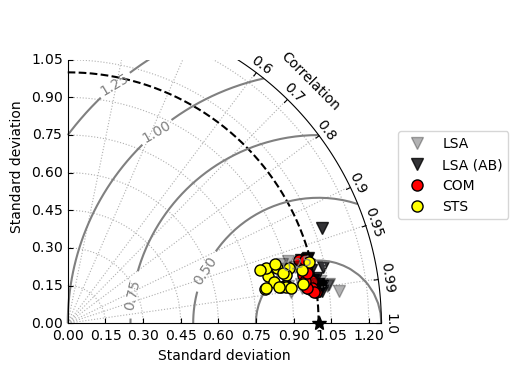

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from taylorDiagram import TaylorDiagram

STNS = np.loadtxt("../DATA/Stations.txt", dtype="U2")
VNS  = np.loadtxt("../DATA/Products.txt", dtype="<U10")

# NOTE: STN_DATA/STN_CC/STN_RMSE are not strictly needed for this plot,
# but keeping your structure unchanged.
STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
STN_CC   = xr.open_dataarray("../DATA/STN_CC.nc")
STN_RMSE = xr.open_dataarray("../DATA/STN_RMSE.nc")

STN_AB  = xr.open_dataarray("../DATA/STN_AB.nc")
STN_COM = xr.open_dataarray("../DATA/STN_COM.nc")

# --- Load STS (saved output) ---
STS_DS = xr.open_dataset("../DATA/STN_STS.nc")
# Expect variable name "ET_STS" (fallback: first variable)
if "ET_STS" in STS_DS:
    STN_STS = STS_DS["ET_STS"]          # (Station, datetime)
else:
    STN_STS = STS_DS.to_array().squeeze()  # fallback if file contains a single variable

# COM time window
i_d1 = STN_COM.datetime[0].values
i_dn = STN_COM.datetime[-1].values

# Benchmark PM over COM window
O = STN_DATA.sel(datetime=slice(i_d1, i_dn)).loc[dict(Product="PM")]
sigma_O = O.std(dim=["datetime"])
sigma_Om = sigma_O.mean(dim="Station")

# Remote products over COM window (drop PM + TH)
R = STN_DATA.sel(datetime=slice(i_d1, i_dn)).drop_sel(Product=["PM", "TH"])
sigma_R = R.std(dim=["datetime"])
sigma_Rm = sigma_R.mean(dim="Station")

# Correlations for remotes
R_CC = xr.corr(O, R, dim="datetime")
R_CCm = R_CC.mean(dim="Station")

# AB stats (assumes STN_AB already corresponds to the same time window as STN_COM;
# if not, uncomment the next line)
# STN_AB = STN_AB.sel(datetime=slice(i_d1, i_dn))

sigma_AB = STN_AB.std(dim=["datetime"])
sigma_ABm = sigma_AB.mean(dim="Station")

AB_CC = xr.corr(O, STN_AB, dim="datetime")
AB_CCm = AB_CC.mean(dim="Station")

# COM stats
sigma_COM = STN_COM.std(dim=["datetime"])
sigma_COMm = sigma_COM.mean(dim="Station")

COM_CC = xr.corr(O, STN_COM, dim="datetime")
COM_CCm = COM_CC.mean(dim="Station")

# --- STS stats over the same COM window ---
STN_STS = STN_STS.sel(datetime=slice(i_d1, i_dn))
sigma_STS = STN_STS.std(dim=["datetime"])
sigma_STSm = sigma_STS.mean(dim="Station")

STS_CC = xr.corr(O, STN_STS, dim="datetime")
STS_CCm = STS_CC.mean(dim="Station")

# Sort index based on mean RMSE of the original remote products (as you did)
R_E = R - O
R_RMSE = np.sqrt((R_E**2).mean(dim="datetime"))
R_RMSEm = R_RMSE.mean(dim="Station")
sri = np.argsort(R_RMSEm)

i_markers = (["v", "o", "o", "^", "o", "v", "o", "v", "^", "v"])
colors = plt.matplotlib.cm.magma(np.linspace(0, 1, len(sri) + 1))

fig = plt.figure(figsize=(5, 3.5))
dia = TaylorDiagram(1, fig=fig, extend=False, label="PM", srange=(0, 1.25))

# We'll keep references to legend handles explicitly (more robust than index-picking)
h_lsa_r = None
h_lsa_ab = None
h_com = None
h_sts = None

for j in range(len(STNS)):
    for i in range(0, 1):
        # Remote LSA-like (original) sample
        h_lsa_r = dia.add_sample(
            sigma_R[j, sri[i]].values / sigma_O[j].values,
            R_CC[j, sri[i]].values,
            marker=i_markers[sri[i].values], ms=8, ls="", alpha=0.3,
            mfc=colors[i], mec="k",
            label=R_CC.Product.values[sri[i]]
        )
        # AB sample
        h_lsa_ab = dia.add_sample(
            sigma_AB[j, sri[i]].values / sigma_O[j].values,
            AB_CC[j, sri[i]].values,
            marker=i_markers[sri[i].values], ms=8, ls="", alpha=0.8,
            mfc=colors[i], mec="k",
            label=AB_CC.Product.values[sri[i]], zorder=1
        )

    # COM sample (per station)
    h_com = dia.add_sample(
        sigma_COM[j].values / sigma_O[j].values,
        COM_CC[j].values,
        marker="o", ms=8, ls="",
        mfc="red", mec="black",
        label="COM", zorder=2
    )

    # STS sample (per station) — choose a distinct marker/color
    h_sts = dia.add_sample(
        sigma_STS[j].values / sigma_O[j].values,
        STS_CC[j].values,
        marker="o", ms=8, ls="",
        mfc="yellow", mec="black",
        label="STS", zorder=3
    )

dia.add_grid(ls=":")
contours = dia.add_contours(levels=6, colors="0.5")
plt.clabel(contours, inline=1, fontsize=10, fmt="%.2f")

ax = plt.gca()

# Legend: show only the key items (PM is the reference label in the diagram)
# Keep your renaming: "LSA (AB)".
handles = []
labels = []

if h_lsa_r is not None:
    handles.append(h_lsa_r)
    labels.append("LSA")

if h_lsa_ab is not None:
    handles.append(h_lsa_ab)
    labels.append("LSA (AB)")

if h_com is not None:
    handles.append(h_com)
    labels.append("COM")

if h_sts is not None:
    handles.append(h_sts)
    labels.append("STS")

ax.legend(handles, labels, loc="center left", bbox_to_anchor=(1.02, 0.6))

plt.tight_layout()
ax.set_ylim(-0.1, 1.05)

plt.savefig("ET4I_Taylor_LSA_COM_STS.png", dpi=300, bbox_inches="tight")
